# Exploring Argo

In [91]:
# imports
import os
import glob
import numpy as np

from matplotlib import pyplot as plt
import datetime

import xarray
import pysolar

# Load up one

In [21]:
ifile = os.path.join(os.getenv('OS_DATA'), 'Argo', 'SOCCOM_GO-BGC_HiResQC_LIAR_26Jun2025_netcdf',
                     #'4903587_HRQC.nc'
                     '1902367QC.nc'
                     #'5906312_HRQC.nc'
                    )

In [22]:
ds = xarray.open_dataset(ifile)

## List of them all

In [58]:
all_files = glob.glob(os.path.join(os.getenv('OS_DATA'), 'Argo', 
                                   'SOCCOM_GO-BGC_HiResQC_LIAR_26Jun2025_netcdf',
                                   '*.nc'))
len(all_files)

685

# Examine

In [25]:
ds

<xarray.Dataset> Size: 8MB
Dimensions:              (N_PROF: 14, N_LEVELS: 1585, NPARAMETER: 53)
Dimensions without coordinates: N_PROF, N_LEVELS, NPARAMETER
Data variables: (12/76)
    Cruise               |S11 11B ...
    Station              (N_PROF) int32 56B ...
    Lon                  (N_PROF) float64 112B ...
    Lat                  (N_PROF) float64 112B ...
    Lat_QF               (N_PROF) |S1 14B ...
    Lat_QFA              (N_PROF) float64 112B ...
    ...                   ...
    Type                 |S1 1B ...
    mon_day_yr           (N_PROF) |S10 140B ...
    hh_mm                (N_PROF) |S5 70B ...
    Parameters           (NPARAMETER) |S19 1kB ...
    JULD                 (N_PROF) datetime64[ns] 112B ...
    REFERENCE_DATE_TIME  object 8B ...
Attributes:
    Comments:  \n//0\n//<Encoding>UTF-8</Encoding>\n//File updated on 06/24/2...

In [59]:
ds.b_bp700_QF

<xarray.DataArray 'b_bp700_QF' (N_PROF: 14, N_LEVELS: 1585)> Size: 22kB
[22190 values with dtype=|S1]
Dimensions without coordinates: N_PROF, N_LEVELS

# Simple plot

In [65]:
prof = ds.isel(N_PROF=3)
prof

<xarray.Dataset> Size: 580kB
Dimensions:              (N_LEVELS: 1585, NPARAMETER: 53)
Dimensions without coordinates: N_LEVELS, NPARAMETER
Data variables: (12/76)
    Cruise               |S11 11B ...
    Station              int32 4B ...
    Lon                  float64 8B ...
    Lat                  float64 8B ...
    Lat_QF               |S1 1B ...
    Lat_QFA              float64 8B ...
    ...                   ...
    Type                 |S1 1B ...
    mon_day_yr           |S10 10B ...
    hh_mm                |S5 5B ...
    Parameters           (NPARAMETER) |S19 1kB ...
    JULD                 datetime64[ns] 8B ...
    REFERENCE_DATE_TIME  object 8B ...
Attributes:
    Comments:  \n//0\n//<Encoding>UTF-8</Encoding>\n//File updated on 06/24/2...

In [88]:
prof.mon_day_yr.values

array(b'04/17/2025', dtype='|S10')

In [89]:
prof.JULD

<xarray.DataArray 'JULD' ()> Size: 8B
array('2025-04-17T10:50:59.999995392', dtype='datetime64[ns]')
Attributes:
    long_name:      Julian day (UTC) of the station relative to REFERENCE_DAT...
    standard_name:  time
    conventions:    Relative julian days with decimal part (as parts of day)
    NOTES:          JULD not a FloatViz variable,  but added for convenience ...

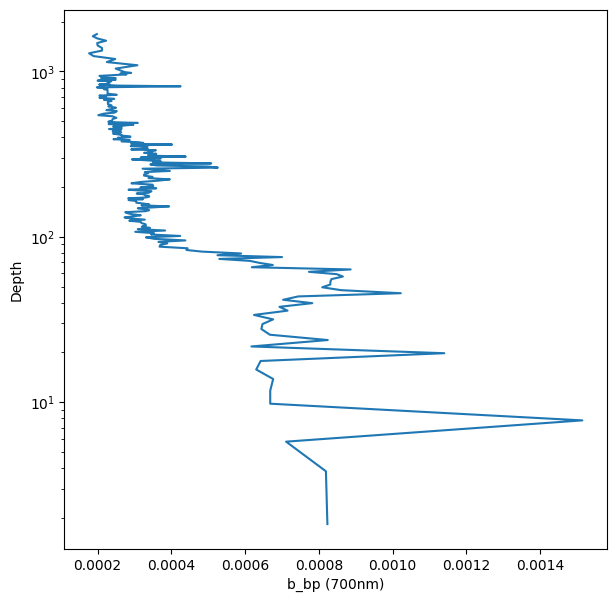

In [76]:
iprof = 3
ok = np.isfinite(ds.b_bp700.data[iprof,:])
#
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.plot(ds.b_bp700.data[iprof,ok], ds.Depth.data[iprof,ok]) 
#
#ax.set_ylim(500.,0)
#
ax.set_xlabel('b_bp (700nm)')
ax.set_ylabel('Depth')
#
ax.set_yscale('log')
#
plt.show()

In [70]:
ds.b_bp700_QF.data[iprof,ok] == b'0'

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [48]:
ds.b_bp700[13]

<xarray.DataArray 'b_bp700' (N_LEVELS: 1585)> Size: 13kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(1585,))
Dimensions without coordinates: N_LEVELS
Attributes:
    units:    1/m

In [46]:
has_value = np.isfinite(ds.b_bp700.data[:,-100:])
np.any(has_value, axis=1)

array([False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True])

In [50]:
ds.b_bp700.data[-2,-100:]

array([     nan, 0.000658,      nan,      nan, 0.000632,      nan,
            nan, 0.000629,      nan,      nan, 0.000662,      nan,
            nan, 0.000645,      nan,      nan, 0.000674,      nan,
            nan, 0.000677,      nan,      nan, 0.000601,      nan,
            nan, 0.000641,      nan,      nan, 0.00063 ,      nan,
            nan, 0.00064 ,      nan,      nan, 0.000641,      nan,
            nan, 0.000652,      nan,      nan, 0.000642,      nan,
            nan, 0.000641,      nan,      nan, 0.00063 ,      nan,
            nan, 0.000629,      nan,      nan, 0.000674,      nan,
            nan, 0.000611,      nan,      nan, 0.000681,      nan,
            nan, 0.000624,      nan,      nan, 0.00065 ,      nan,
            nan, 0.000653,      nan,      nan, 0.000621,      nan,
            nan, 0.000628,      nan,      nan,      nan, 0.000594,
            nan,      nan,      nan, 0.000659,      nan,      nan,
            nan, 0.000687,      nan,      nan,      nan, 0.000

In [45]:
ds.Pressure.data[-2,-100:]

array([59.96, 59.76, 58.84, 58.  , 57.76, 56.84, 55.92, 55.76, 54.76,
       54.  , 53.72, 52.84, 52.04, 51.84, 50.8 , 50.  , 49.8 , 48.72,
       47.96, 47.64, 46.88, 45.96, 45.8 , 44.72, 43.96, 43.68, 42.76,
       42.  , 41.72, 40.8 , 40.  , 39.84, 38.88, 38.04, 37.84, 36.88,
       36.04, 35.8 , 34.8 , 34.  , 33.76, 32.84, 32.04, 31.76, 30.8 ,
       30.04, 29.84, 28.84, 28.  , 27.76, 26.76, 25.96, 25.72, 24.68,
       24.  , 23.64, 22.84, 22.08, 21.84, 20.84, 20.  , 19.76, 18.68,
       17.96, 17.76, 16.68, 15.96, 15.6 , 14.72, 14.  , 13.68, 12.84,
       12.  , 11.8 , 10.72, 10.6 ,  9.96,  9.6 ,  9.  ,  8.84,  8.04,
        7.8 ,  7.04,  6.76,  6.  ,  5.68,  5.  ,  4.76,  4.04,  3.88,
        3.04,  2.72,  2.04,  1.64,  1.04,  1.  ,  0.88,  0.76,  0.68,
        0.56])

In [94]:
ds.variables

Frozen({'Cruise': <xarray.Variable ()> Size: 11B
[1 values with dtype=|S11], 'Station': <xarray.Variable (N_PROF: 14)> Size: 56B
[14 values with dtype=int32], 'Lon': <xarray.Variable (N_PROF: 14)> Size: 112B
[14 values with dtype=float64], 'Lat': <xarray.Variable (N_PROF: 14)> Size: 112B
[14 values with dtype=float64], 'Lat_QF': <xarray.Variable (N_PROF: 14)> Size: 14B
[14 values with dtype=|S1], 'Lat_QFA': <xarray.Variable (N_PROF: 14)> Size: 112B
[14 values with dtype=float64]
Attributes:
    NOTES:    Variables ending in _QFA are an alternate format (double matrix..., 'IceEvRec': <xarray.Variable (N_PROF: 14, N_LEVELS: 1585)> Size: 178kB
[22190 values with dtype=float64]
Attributes:
    units:    , 'Pressure': <xarray.Variable (N_PROF: 14, N_LEVELS: 1585)> Size: 178kB
array([[1.00200e+03, 1.00008e+03, 9.99800e+02, ...,         nan,         nan,
                nan],
       [1.53208e+03, 1.53004e+03, 1.52820e+03, ...,         nan,         nan,
                nan],
       [1.51364e+0

In [96]:
ds.JULD.values

array(['2025-04-15T07:33:59.999995904', '2025-04-15T16:04:59.999998976',
       '2025-04-16T13:57:00.000004096', '2025-04-17T10:50:59.999995392',
       '2025-04-18T07:47:59.999995904', '2025-04-19T05:39:00.000004608',
       '2025-04-20T06:05:59.999998464', '2025-04-21T06:22:00.000001536',
       '2025-05-01T12:55:00.000004608', '2025-05-11T03:42:59.999996928',
       '2025-05-21T06:48:59.999995904', '2025-05-31T09:39:59.999997952',
       '2025-06-10T13:36:59.999994880', '2025-06-20T17:46:59.999996416'],
      dtype='datetime64[ns]')

----

In [92]:
latitude = 42.206
longitude = -71.382

date = datetime.datetime(2007, 2, 18, 15, 13, 1, 130320, tzinfo=datetime.timezone.utc)

In [93]:
pysolar.solar.get_altitude(latitude, longitude, date)

np.float64(30.914468243599078)

In [ ]:
pysolar.solar.get_position